# 🛡️ CYBER THREAT EXPOSURE ANALYZER

**A real-time vulnerability intelligence dashboard powered by NVD and CISA KEV.**

This notebook:
1. Validates the schema of every API response **before** extraction
2. Pulls live CVE data from the **NIST National Vulnerability Database**
3. Cross-references with the **CISA Known Exploited Vulnerabilities** catalog
4. Computes a documented, deterministic **Risk Score**
5. Generates **six** matplotlib visualizations
6. Produces an **Executive Intelligence Report**

**Data Sources (no auth required):**
- NVD CVE API v2.0 — `https://services.nvd.nist.gov/rest/json/cves/2.0`
- CISA KEV Catalog — `https://www.cisa.gov/sites/default/files/feeds/known_exploited_vulnerabilities.json`

**Runtime:** Google Colab / Jupyter — runs top-to-bottom with no edits.


In [23]:
#  Imports and configuration

import json
import time
import warnings
from datetime import datetime, timedelta, timezone

import requests
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

warnings.filterwarnings("ignore")
matplotlib.rcParams.update({"figure.dpi": 110, "font.family": "DejaVu Sans"})

# ─── Configuration constants ──────────────────────────────────
LOOKBACK_DAYS   = 21          # 3-week analysis window
NVD_PAGE_SIZE   = 2000        # NVD API hard limit per request
NVD_SLEEP_SEC   = 6           # Respect public rate limit (5 req / 30s)
REQUEST_TIMEOUT = 45

NOW       = datetime.now(timezone.utc)
START_DT  = NOW - timedelta(days=LOOKBACK_DAYS)
NVD_START = START_DT.strftime("%Y-%m-%dT%H:%M:%S.000")
NVD_END   = NOW.strftime("%Y-%m-%dT%H:%M:%S.000")

NVD_URL  = "https://services.nvd.nist.gov/rest/json/cves/2.0"
KEV_URL  = "https://www.cisa.gov/sites/default/files/feeds/known_exploited_vulnerabilities.json"

# Risk-engine weights — justification in Cell 11.
W_CVSS, W_KEV, W_RECENCY = 0.50, 0.35, 0.15

print(f"pandas     : {pd.__version__}")
print(f"requests   : {requests.__version__}")
print(f"matplotlib : {matplotlib.__version__}")
print(f"Window     : {START_DT.date()} → {NOW.date()}  ({LOOKBACK_DAYS} days)")


pandas     : 2.2.2
requests   : 2.32.4
matplotlib : 3.10.0
Window     : 2026-05-23 → 2026-06-13  (21 days)


## STEP 1 — Schema Validation

Before extracting any field, we **inspect** the live JSON returned by each API.
This protects the pipeline from silent schema drift.

For each source we will print:
- Top-level keys
- A pretty-printed sample record
- The keys available inside that sample


In [24]:
# NVD schema probe
# Pull a TINY page (1 record) just to inspect the structure.

def safe_get_json(url: str, params: dict | None = None) -> dict:
    """HTTP GET with full error handling. Returns {} on any failure."""
    try:
        r = requests.get(url, params=params, timeout=REQUEST_TIMEOUT)
        r.raise_for_status()
        return r.json()
    except (requests.RequestException, json.JSONDecodeError) as exc:
        print(f"  [WARNING] Request failed for {url}: {exc}")
        return {}

probe_params = {
    "pubStartDate"  : NVD_START,
    "pubEndDate"    : NVD_END,
    "resultsPerPage": 1,
    "startIndex"    : 0,
}

print("Probing NVD API ...")
nvd_probe = safe_get_json(NVD_URL, probe_params)

print("\n── NVD top-level keys ──")
print(list(nvd_probe.keys()))

print(f"\nTotalResults declared by NVD: {nvd_probe.get('totalResults', 'N/A')}")

sample_vulns = nvd_probe.get("vulnerabilities", [])
if sample_vulns:
    sample_cve = sample_vulns[0].get("cve", {})
    print("\n── Sample CVE top-level keys ──")
    print(list(sample_cve.keys()))

    print("\n── Sample CVE (first 1500 chars of pretty JSON) ──")
    print(json.dumps(sample_cve, indent=2)[:1500])
else:
    print("[WARNING] NVD returned no sample. Check connectivity.")


Probing NVD API ...

── NVD top-level keys ──
['resultsPerPage', 'startIndex', 'totalResults', 'format', 'version', 'timestamp', 'vulnerabilities']

TotalResults declared by NVD: 5532

── Sample CVE top-level keys ──
['id', 'sourceIdentifier', 'published', 'lastModified', 'vulnStatus', 'cveTags', 'descriptions', 'metrics', 'weaknesses', 'references']

── Sample CVE (first 1500 chars of pretty JSON) ──
{
  "id": "CVE-2026-9342",
  "sourceIdentifier": "cna@vuldb.com",
  "published": "2026-05-23T23:16:45.143",
  "lastModified": "2026-05-26T18:56:13.353",
  "vulnStatus": "Deferred",
  "cveTags": [],
  "descriptions": [
    {
      "lang": "en",
      "value": "A security flaw has been discovered in SourceCodester Hospitals Patient Records Management System 1.0. Impacted is an unknown function of the file /admin/patients/view_history.php. The manipulation of the argument ID results in sql injection. The attack may be launched remotely. The exploit has been released to the public and may be 

In [11]:
# CISA KEV schema probe
print("Probing CISA KEV catalog ...")
kev_probe = safe_get_json(KEV_URL)

print("\n── KEV top-level keys ──")
print(list(kev_probe.keys()))

print(f"\nCatalog version : {kev_probe.get('catalogVersion', 'N/A')}")
print(f"Date released   : {kev_probe.get('dateReleased',   'N/A')}")
print(f"Vuln count      : {kev_probe.get('count',          'N/A')}")

kev_sample_list = kev_probe.get("vulnerabilities", [])
if kev_sample_list:
    print("\n── Sample KEV entry keys ──")
    print(list(kev_sample_list[0].keys()))

    print("\n── Sample KEV entry ──")
    print(json.dumps(kev_sample_list[0], indent=2))
else:
    print("[WARNING] KEV returned no sample.")


Probing CISA KEV catalog ...

── KEV top-level keys ──
['title', 'catalogVersion', 'dateReleased', 'count', 'vulnerabilities']

Catalog version : 2026.06.12
Date released   : 2026-06-12T16:46:48.0549Z
Vuln count      : 1619

── Sample KEV entry keys ──
['cveID', 'vendorProject', 'product', 'vulnerabilityName', 'dateAdded', 'shortDescription', 'requiredAction', 'dueDate', 'knownRansomwareCampaignUse', 'notes', 'cwes']

── Sample KEV entry ──
{
  "cveID": "CVE-2026-35273",
  "vendorProject": "Oracle",
  "product": " PeopleSoft Enterprise PeopleTools",
  "vulnerabilityName": "Oracle PeopleSoft Enterprise PeopleTools Missing Authentication for Critical Function Vulnerability",
  "dateAdded": "2026-06-12",
  "shortDescription": "Oracle PeopleSoft Enterprise PeopleTools contains a missing authentication for critical function vulnerability which could allow an unauthenticated attacker to obtain takeover of PeopleSoft Enterprise PeopleTools.",
  "requiredAction": "Apply mitigations in accordan

## STEP 2 — NVD Data Collection

Now that we have **confirmed** the field structure, we pull the full
window of CVE data using paginated requests with rate-limit-friendly delays.
All extractions use `.get()` with defaults so missing fields never raise.


In [25]:
# Fetch all NVD CVEs in the analysis window

def fetch_nvd_all(start: str, end: str) -> list:
    """Page through NVD until totalResults is exhausted."""
    items, idx = [], 0
    print("Fetching NVD CVEs ...")

    while True:
        params = {
            "pubStartDate"  : start,
            "pubEndDate"    : end,
            "resultsPerPage": NVD_PAGE_SIZE,
            "startIndex"    : idx,
        }
        payload = safe_get_json(NVD_URL, params)
        if not payload:
            print(f"  [WARNING] Empty payload at index {idx} — stopping.")
            break

        total = payload.get("totalResults", 0)
        page  = payload.get("vulnerabilities", []) or []
        items.extend(page)
        print(f"  Retrieved {len(items):,} / {total:,}", end="\r")

        if len(items) >= total or not page:
            break

        idx += NVD_PAGE_SIZE
        time.sleep(NVD_SLEEP_SEC)

    print(f"\nNVD fetch complete: {len(items):,} CVE items")
    return items

raw_nvd = fetch_nvd_all(NVD_START, NVD_END)


Fetching NVD CVEs ...
  Retrieved 5,532 / 5,532
NVD fetch complete: 5,532 CVE items


In [27]:
# Safe field extraction & DataFrame construction
# Security reasoning: never trust a remote schema. Each .get() falls
# back to a safe default so a missing key cannot crash a SOC pipeline.

def extract_cvss(cve: dict) -> tuple[float, str]:
    """Return (score, severity) using v3.1 > v3.0 > v2 priority."""
    metrics = cve.get("metrics", {}) or {}

    for key in ("cvssMetricV31", "cvssMetricV30"):
        entries = metrics.get(key) or []
        if entries:
            data = entries[0].get("cvssData", {}) or {}
            score = data.get("baseScore")
            sev   = (data.get("baseSeverity") or "UNKNOWN").upper()
            if isinstance(score, (int, float)):
                return float(score), sev

    entries_v2 = metrics.get("cvssMetricV2") or []
    if entries_v2:
        data  = entries_v2[0].get("cvssData", {}) or {}
        score = data.get("baseScore")
        if isinstance(score, (int, float)):
            score = float(score)
            if   score >= 7.0: sev = "HIGH"
            elif score >= 4.0: sev = "MEDIUM"
            elif score > 0:    sev = "LOW"
            else:              sev = "NONE"
            return score, sev

    return np.nan, "UNKNOWN"


def extract_vendor_product(cve: dict) -> tuple[str, str]:
    """Walk the configurations tree safely. Returns ('Unknown','Unknown') on miss."""
    try:
        for cfg in (cve.get("configurations") or []):
            for node in (cfg.get("nodes") or []):
                for cpe in (node.get("cpeMatch") or []):
                    uri = cpe.get("criteria", "") or ""
                    parts = uri.split(":")
                    if len(parts) >= 5:
                        vendor  = parts[3].replace("_", " ").title()
                        product = parts[4].replace("_", " ").title()
                        if vendor and vendor not in ("*", "-", "N A"):
                            return vendor, product
    except Exception:
        pass
    return "Unknown", "Unknown"


def extract_description(cve: dict) -> str:
    """Prefer English description; fall back to any available text."""
    descs = cve.get("descriptions") or []
    for d in descs:
        if d.get("lang") == "en" and d.get("value"):
            return d["value"]
    if descs and descs[0].get("value"):
        return descs[0]["value"]
    return "No description available."


def parse_published(cve: dict) -> datetime:
    raw = cve.get("published", "") or ""
    try:
        return datetime.fromisoformat(raw.replace("Z", "+00:00"))
    except Exception:
        return NOW


#  Build the DataFrame
records = []
for item in raw_nvd:
    cve = (item or {}).get("cve", {}) or {}
    cve_id = cve.get("id", "UNKNOWN-CVE")

    cvss_score, severity = extract_cvss(cve)
    vendor, product      = extract_vendor_product(cve)
    pub_dt               = parse_published(cve)

    records.append({
        "CVE_ID"      : cve_id,
        "Published"   : pub_dt,
        "CVSS"        : cvss_score,
        "Severity"    : severity,
        "Vendor"      : vendor,
        "Product"     : product,
        "Description" : extract_description(cve),
        "VulnStatus"  : cve.get("vulnStatus", "Unknown"),
    })

cve_df = pd.DataFrame(records)
if not cve_df.empty:
    cve_df["Published"] = pd.to_datetime(cve_df["Published"], utc=True, errors="coerce")
    cve_df["PubDate"]   = cve_df["Published"].dt.date
    cve_df["DaysOld"]   = ((NOW - cve_df["Published"]).dt.total_seconds() / 86400).clip(lower=0)

print(f"Rows         : {len(cve_df):,}")
print(f"Columns      : {list(cve_df.columns)}")
print(f"\nNull counts:\n{cve_df.isna().sum()}")
print(f"\nSample records:")
print(cve_df[["CVE_ID", "Published", "CVSS", "Severity", "Vendor", "Product", "VulnStatus"]].head(5).to_string(index=False))


Rows         : 5,532
Columns      : ['CVE_ID', 'Published', 'CVSS', 'Severity', 'Vendor', 'Product', 'Description', 'VulnStatus', 'PubDate', 'DaysOld']

Null counts:
CVE_ID           0
Published        0
CVSS           786
Severity         0
Vendor           0
Product          0
Description      0
VulnStatus       0
PubDate          0
DaysOld          0
dtype: int64

Sample records:
       CVE_ID                        Published  CVSS Severity  Vendor Product VulnStatus
CVE-2026-9342 2026-05-23 23:16:45.143000+00:00   6.3   MEDIUM Unknown Unknown   Deferred
CVE-2026-9343 2026-05-23 23:16:45.300000+00:00   6.3   MEDIUM Unknown Unknown   Deferred
CVE-2026-9344 2026-05-24 01:16:26.717000+00:00   8.8     HIGH Unknown Unknown   Deferred
CVE-2026-9345 2026-05-24 02:16:44.807000+00:00   8.8     HIGH Unknown Unknown   Deferred
CVE-2026-9346 2026-05-24 02:16:45.150000+00:00   8.8     HIGH Unknown Unknown   Deferred


In [28]:
# Post-parse sanity checks
print("=" * 60)
print(" PARSED DATA VALIDATION")
print("=" * 60)
print(f"Total rows                       : {len(cve_df):,}")
print(f"Rows with a CVSS score           : {cve_df['CVSS'].notna().sum():,}")
print(f"Rows missing CVSS (awaiting NVD) : {cve_df['CVSS'].isna().sum():,}")
print(f"Distinct vendors identified      : {cve_df['Vendor'].nunique():,}")
print(f"Distinct severities              : {cve_df['Severity'].unique().tolist()}")
print(f"VulnStatus breakdown:")
print(cve_df["VulnStatus"].value_counts().to_string())
print("=" * 60)


 PARSED DATA VALIDATION
Total rows                       : 5,532
Rows with a CVSS score           : 4,746
Rows missing CVSS (awaiting NVD) : 786
Distinct vendors identified      : 216
Distinct severities              : ['MEDIUM', 'HIGH', 'LOW', 'CRITICAL', 'UNKNOWN']
VulnStatus breakdown:
VulnStatus
Deferred               2093
Analyzed               2088
Awaiting Analysis       792
Received                236
Undergoing Analysis     174
Modified                119
Rejected                 30


## STEP 3 — CISA KEV Integration

We load the **Known Exploited Vulnerabilities** catalog and join it
against our NVD data. KEV entries are the highest-confidence signal
that a CVE is being actively used by threat actors in the wild.


In [29]:
# Load CISA KEV catalog and join
kev_payload = safe_get_json(KEV_URL)
kev_items   = kev_payload.get("vulnerabilities", []) or []

kev_records = []
for v in kev_items:
    kev_records.append({
        "CVE_ID"         : v.get("cveID", ""),
        "KEV_Vendor"     : v.get("vendorProject", "Unknown"),
        "KEV_Product"    : v.get("product",       "Unknown"),
        "KEV_DateAdded"  : v.get("dateAdded",     ""),
        "RequiredAction" : v.get("requiredAction", "Apply mitigations per vendor guidance."),
    })

kev_df = pd.DataFrame(kev_records)
print(f"CISA KEV catalog loaded: {len(kev_df):,} entries")
print(kev_df.head(3).to_string(index=False))

# ─── Join: mark CVEs that appear in KEV ───────────────────────
kev_ids = set(kev_df["CVE_ID"])
cve_df["KnownExploited"] = cve_df["CVE_ID"].isin(kev_ids)

match_count = cve_df["KnownExploited"].sum()
print(f"\nNVD ↔ KEV matches in window: {match_count:,} "
      f"({match_count / max(len(cve_df), 1) * 100:.2f}% of fetched CVEs)")


CISA KEV catalog loaded: 1,619 entries
        CVE_ID KEV_Vendor                        KEV_Product KEV_DateAdded                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           RequiredAction
CVE-2026-35273     Oracle  PeopleSoft Enterprise PeopleTools    2026-06-12 Apply mitigations in accordance with vendor instructions, ensuring compliance with CISA’s BOD 26-04 Prioritizing Security Updates Based on Risk (see URL in Notes) guidance and CISA’s “Forensics Triage Requirements” (see URL in Notes). Follow applicable BOD 26-04 guidance for cloud services or discontinue use of the produ

## STEP 4 — Risk Prioritization Engine

### Formula



| Factor | Weight | Why |
|---|---|---|
| **CVSS** (normalized 0–1) | **0.50** | Industry-standard quantitative measure of exploitability + impact. The single most reliable technical severity signal. |
| **KEV flag** (binary 0/1) | **0.35** | CISA evidence of *active* exploitation. Per BOD 22-01, KEV-listed CVEs **must** be remediated on accelerated timelines. |
| **Recency** (linear decay) | **0.15** | New CVEs face a window where exploits appear before patches deploy. Linear decay from 1.0 (today) to 0.0 (window edge). |

### Classification Tiers
| RiskScore | Tier |
|---|---|
| ≥ 85 | Immediate Action |
| 70 – 84.99 | Critical |
| 55 – 69.99 | High |
| 35 – 54.99 | Medium |
| < 35 | Low |


In [31]:
# Risk score + classification

def compute_risk(row) -> float:
    cvss      = row["CVSS"] if pd.notna(row["CVSS"]) else 0.0
    cvss_norm = cvss / 10.0
    kev_flag  = 1.0 if row["KnownExploited"] else 0.0
    recency   = max(0.0, 1.0 - (row["DaysOld"] / LOOKBACK_DAYS))
    raw = (W_CVSS * cvss_norm) + (W_KEV * kev_flag) + (W_RECENCY * recency)
    return round(min(raw, 1.0) * 100, 2)

def classify(score: float) -> str:
    if   score >= 85: return "Immediate Action"
    elif score >= 70: return "Critical"
    elif score >= 55: return "High"
    elif score >= 35: return "Medium"
    else:             return "Low"

if not cve_df.empty:
    cve_df["RiskScore"] = cve_df.apply(compute_risk, axis=1)
    cve_df["RiskTier"]  = cve_df["RiskScore"].apply(classify)

    print("Risk score computed.")
    print("\nRisk tier distribution:")
    print(cve_df["RiskTier"].value_counts().to_string())

    print("\nTop 10 by RiskScore:")
    print(
        cve_df.nlargest(10, "RiskScore")[
            ["CVE_ID", "CVSS", "Severity", "KnownExploited",
             "DaysOld", "RiskScore", "RiskTier", "Vendor"]
        ].to_string(index=False)
    )


Risk score computed.

Risk tier distribution:
RiskTier
Medium              3246
Low                 1902
High                 374
Immediate Action       6
Critical               4

Top 10 by RiskScore:
        CVE_ID  CVSS Severity  KnownExploited   DaysOld  RiskScore         RiskTier     Vendor
CVE-2026-35273   9.8 CRITICAL            True  2.764997      97.03 Immediate Action     Oracle
CVE-2026-10520  10.0 CRITICAL            True  4.265205      96.95 Immediate Action     Ivanti
CVE-2026-50751   9.3 CRITICAL            True  5.431911      92.62 Immediate Action Checkpoint
CVE-2026-11645   8.8     HIGH            True  4.931737      90.48 Immediate Action     Google
CVE-2026-48027   9.8 CRITICAL            True 17.223468      86.70 Immediate Action         Nx
CVE-2026-45247   9.8 CRITICAL            True 18.306831      85.92 Immediate Action   Mirasvit
CVE-2025-48595   8.4     HIGH            True 12.015409      83.42         Critical     Google
CVE-2026-20245   7.8     HIGH         

## STEP 5 — Analytics Summary

Aggregate KPIs derived purely from the live dataset.


In [32]:
# Aggregate analytics
total_cves     = len(cve_df)
avg_cvss       = round(cve_df["CVSS"].mean(skipna=True), 2) if total_cves else 0.0
median_cvss    = round(cve_df["CVSS"].median(skipna=True), 2) if total_cves else 0.0
critical_count = int((cve_df["Severity"] == "CRITICAL").sum())
high_count     = int((cve_df["Severity"] == "HIGH").sum())
kev_count      = int(cve_df["KnownExploited"].sum())
imm_action_cnt = int((cve_df["RiskTier"] == "Immediate Action").sum())

daily_trend = (
    cve_df.groupby("PubDate")["CVE_ID"].count()
          .rename("DailyCVEs")
          .reset_index()
          .sort_values("PubDate")
)

print("=" * 60)
print(" CYBER THREAT EXPOSURE — KEY METRICS")
print("=" * 60)
print(f"  Total CVEs ({LOOKBACK_DAYS}-day window) : {total_cves:,}")
print(f"  Critical-severity CVEs        : {critical_count:,}")
print(f"  High-severity CVEs            : {high_count:,}")
print(f"  Known-Exploited (KEV) CVEs    : {kev_count:,}")
print(f"  Immediate-Action CVEs         : {imm_action_cnt:,}")
print(f"  Average CVSS                  : {avg_cvss}")
print(f"  Median  CVSS                  : {median_cvss}")
print(f"  Distinct vendors              : {cve_df['Vendor'].nunique():,}")
print("=" * 60)
print("\nDaily publication trend (first 10 days):")
print(daily_trend.head(10).to_string(index=False))



 CYBER THREAT EXPOSURE — KEY METRICS
  Total CVEs (21-day window) : 5,532
  Critical-severity CVEs        : 452
  High-severity CVEs            : 2,103
  Known-Exploited (KEV) CVEs    : 10
  Immediate-Action CVEs         : 6
  Average CVSS                  : 6.93
  Median  CVSS                  : 7.2
  Distinct vendors              : 216

Daily publication trend (first 10 days):
   PubDate  DailyCVEs
2026-05-23          2
2026-05-24         62
2026-05-25        188
2026-05-26        280
2026-05-27        717
2026-05-28        547
2026-05-29        251
2026-05-30         48
2026-05-31         50
2026-06-01        377


## STEP 6 — Visualizations
Six matplotlib figures rendered directly from the live DataFrame.


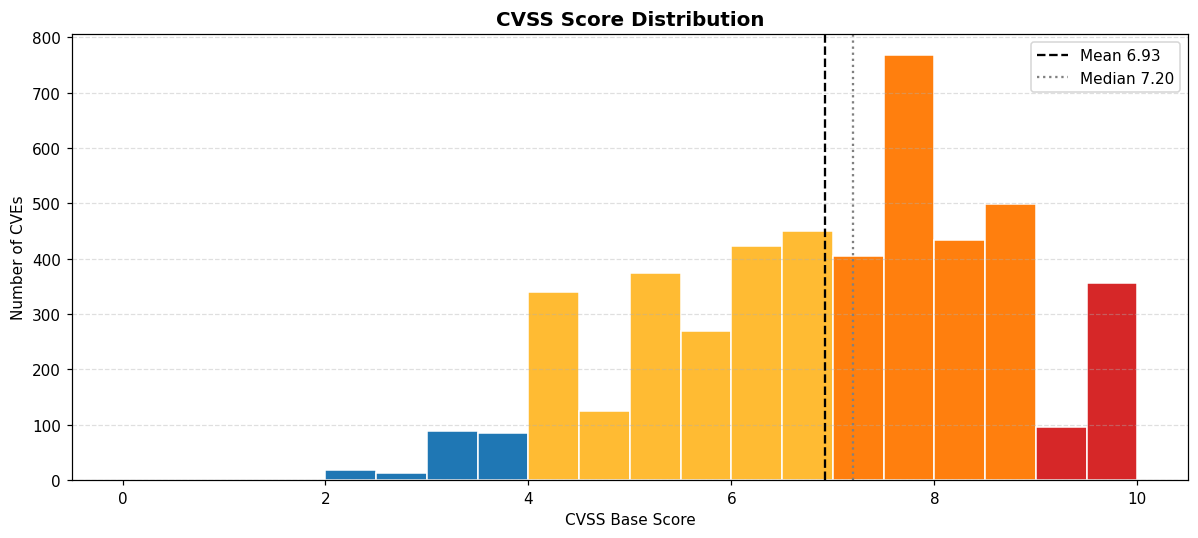

In [33]:
# Histogram of CVSS scores
cvss_valid = cve_df["CVSS"].dropna()

fig, ax = plt.subplots(figsize=(11, 5))
if not cvss_valid.empty:
    bins = np.arange(0, 10.5, 0.5)
    counts, edges, patches = ax.hist(cvss_valid, bins=bins, edgecolor="white")
    for patch in patches:
        mid = patch.get_x() + patch.get_width() / 2
        if   mid >= 9.0: patch.set_facecolor("#d62728")  # Critical
        elif mid >= 7.0: patch.set_facecolor("#ff7f0e")  # High
        elif mid >= 4.0: patch.set_facecolor("#ffbb33")  # Medium
        else:            patch.set_facecolor("#1f77b4")  # Low
    ax.axvline(cvss_valid.mean(),   ls="--", color="black", label=f"Mean {cvss_valid.mean():.2f}")
    ax.axvline(cvss_valid.median(), ls=":",  color="gray",  label=f"Median {cvss_valid.median():.2f}")
    ax.legend()
ax.set_title("CVSS Score Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("CVSS Base Score")
ax.set_ylabel("Number of CVEs")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


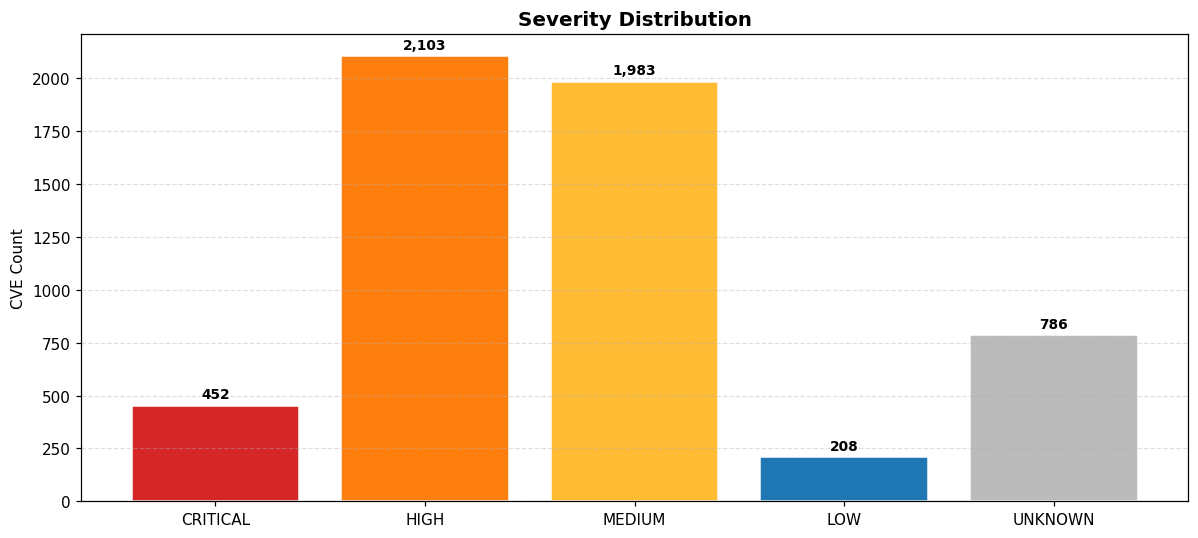

In [34]:
# Severity distribution bar chart
sev_order  = ["CRITICAL", "HIGH", "MEDIUM", "LOW", "NONE", "UNKNOWN"]
sev_color  = {"CRITICAL":"#d62728","HIGH":"#ff7f0e","MEDIUM":"#ffbb33",
              "LOW":"#1f77b4","NONE":"#888","UNKNOWN":"#bbb"}

sev_counts = cve_df["Severity"].value_counts()
labels = [s for s in sev_order if s in sev_counts.index]
vals   = [sev_counts[s] for s in labels]
colors = [sev_color[s] for s in labels]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(labels, vals, color=colors, edgecolor="white")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + max(vals)*0.01,
            f"{v:,}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("Severity Distribution", fontsize=13, fontweight="bold")
ax.set_ylabel("CVE Count")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


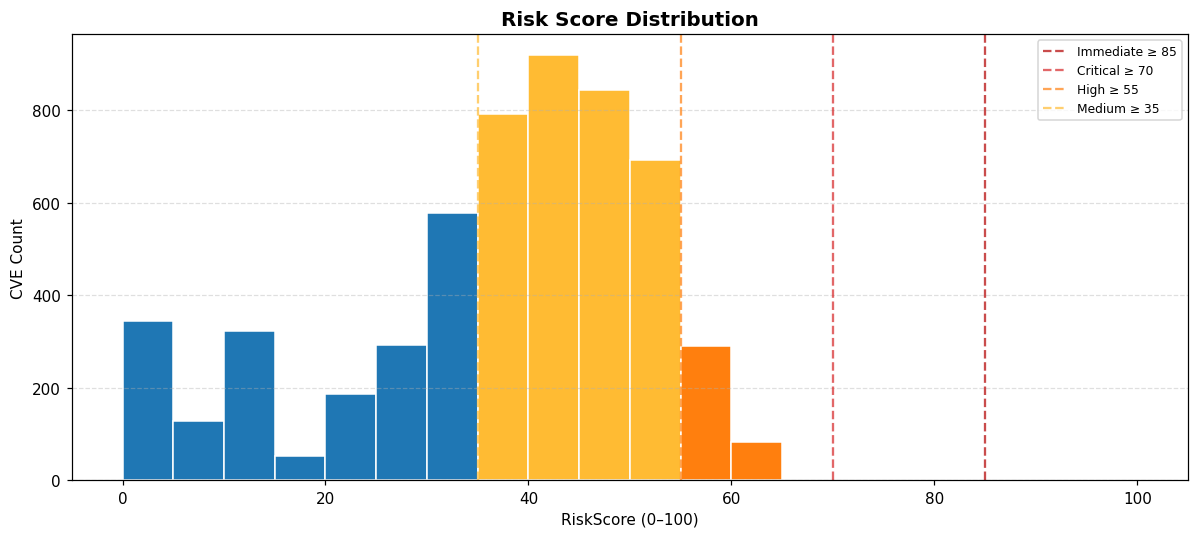

In [35]:
# Risk score distribution
fig, ax = plt.subplots(figsize=(11, 5))
bins_r = np.arange(0, 105, 5)
counts_r, edges_r, patches_r = ax.hist(cve_df["RiskScore"], bins=bins_r, edgecolor="white")
for patch in patches_r:
    mid = patch.get_x() + patch.get_width() / 2
    if   mid >= 85: patch.set_facecolor("#b30000")
    elif mid >= 70: patch.set_facecolor("#d62728")
    elif mid >= 55: patch.set_facecolor("#ff7f0e")
    elif mid >= 35: patch.set_facecolor("#ffbb33")
    else:           patch.set_facecolor("#1f77b4")

for t, c, lbl in [(85,"#b30000","Immediate"),(70,"#d62728","Critical"),
                  (55,"#ff7f0e","High"),(35,"#ffbb33","Medium")]:
    ax.axvline(t, ls="--", color=c, alpha=0.7, label=f"{lbl} ≥ {t}")
ax.legend(fontsize=8)
ax.set_title("Risk Score Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("RiskScore (0–100)")
ax.set_ylabel("CVE Count")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


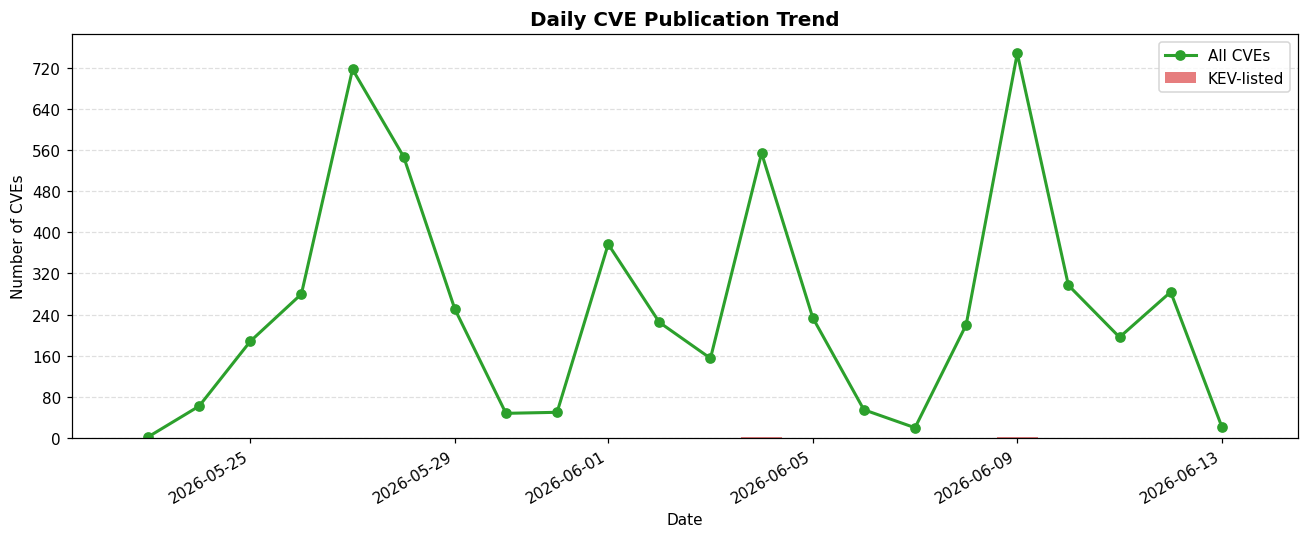

In [36]:
# Daily publication trend
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(daily_trend["PubDate"], daily_trend["DailyCVEs"],
        marker="o", linewidth=2, color="#2ca02c", label="All CVEs")

kev_daily = (
    cve_df[cve_df["KnownExploited"]]
    .groupby("PubDate")["CVE_ID"].count()
    .reindex(daily_trend["PubDate"], fill_value=0)
)
ax.bar(daily_trend["PubDate"], kev_daily.values, color="#d62728",
       alpha=0.6, label="KEV-listed")

ax.set_title("Daily CVE Publication Trend", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Number of CVEs")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


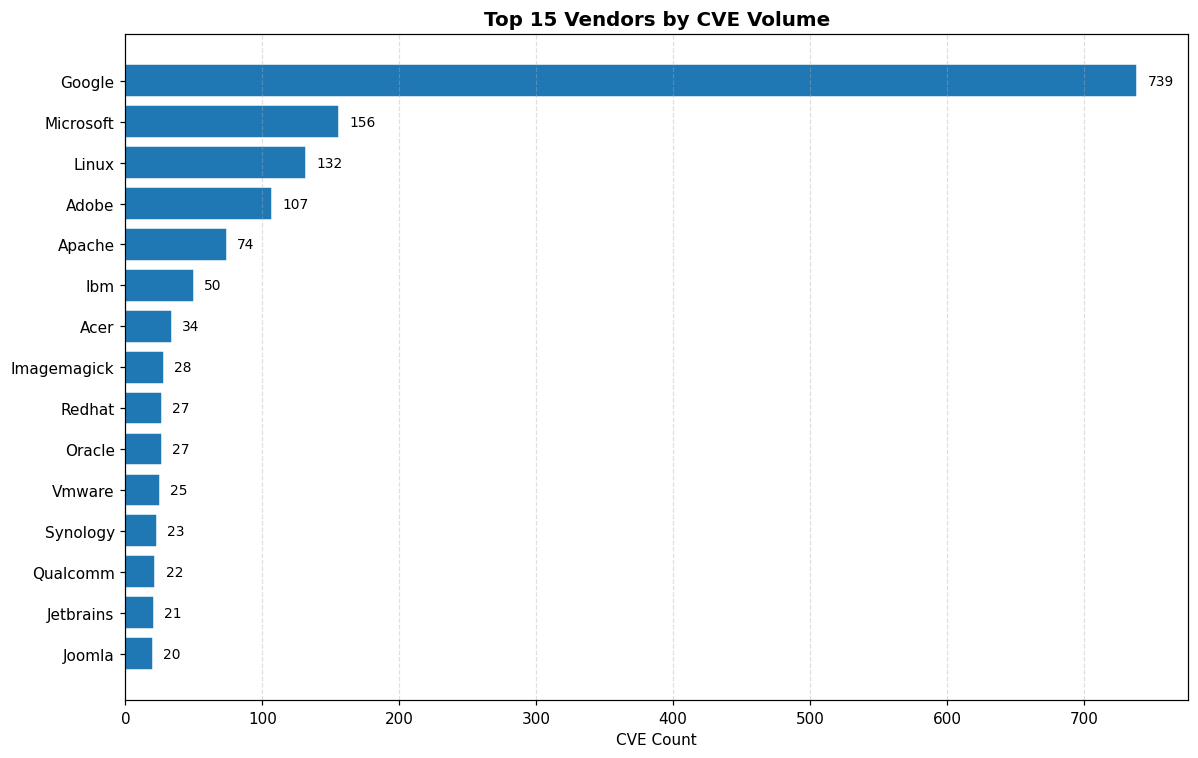

In [37]:
#  Top vendors by CVE count
top_vendors = (
    cve_df[cve_df["Vendor"] != "Unknown"]["Vendor"]
    .value_counts()
    .head(15)
)

fig, ax = plt.subplots(figsize=(11, 7))
if not top_vendors.empty:
    bars_v = ax.barh(top_vendors.index[::-1], top_vendors.values[::-1],
                     color="#1f77b4", edgecolor="white")
    for b, v in zip(bars_v, top_vendors.values[::-1]):
        ax.text(v + max(top_vendors.values)*0.01, b.get_y() + b.get_height()/2,
                f"{v:,}", va="center", fontsize=9)
ax.set_title("Top 15 Vendors by CVE Volume", fontsize=13, fontweight="bold")
ax.set_xlabel("CVE Count")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


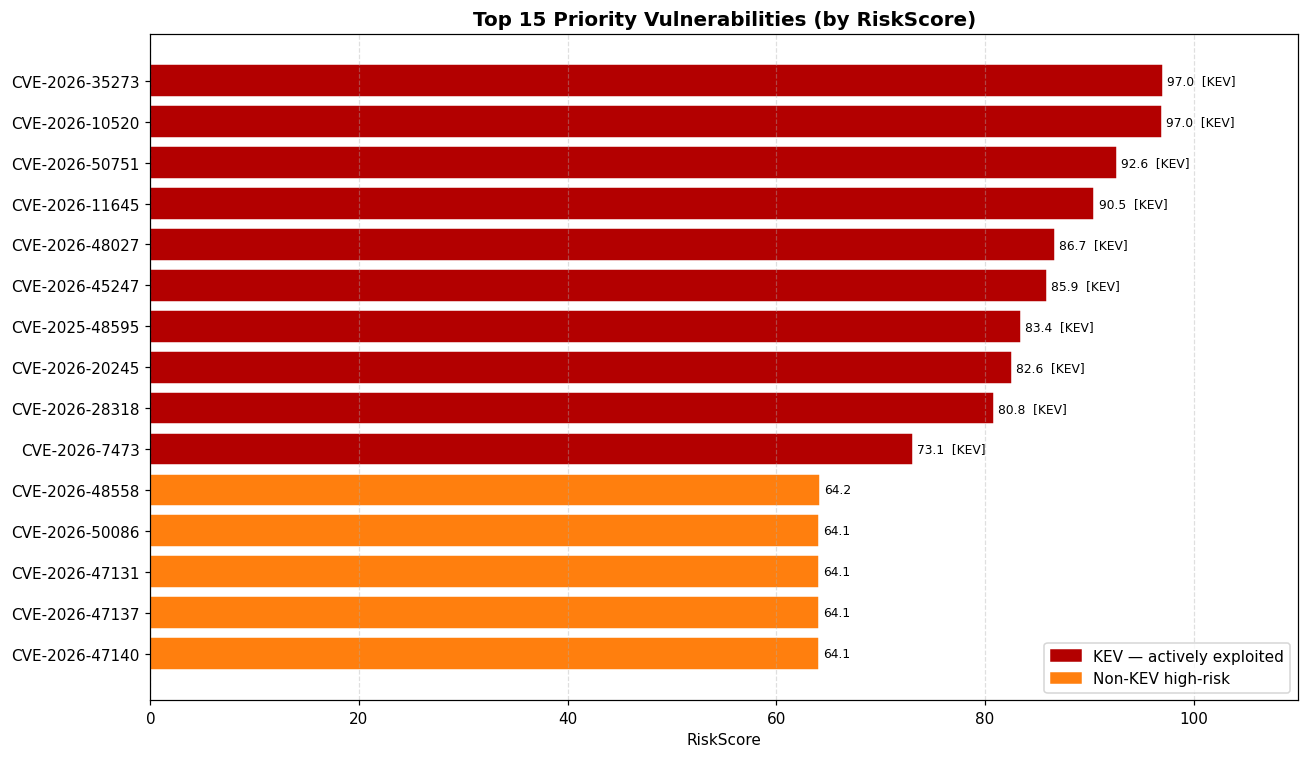

In [38]:
# Top 15 CVEs by RiskScore
top_risk = cve_df.nlargest(15, "RiskScore").copy()

fig, ax = plt.subplots(figsize=(12, 7))
colors = ["#b30000" if k else "#ff7f0e" for k in top_risk["KnownExploited"][::-1]]
labels = top_risk["CVE_ID"][::-1]
scores = top_risk["RiskScore"][::-1]

bars_t = ax.barh(labels, scores, color=colors, edgecolor="white")
for b, s, k in zip(bars_t, scores, top_risk["KnownExploited"][::-1]):
    tag = "  [KEV]" if k else ""
    ax.text(s + 0.4, b.get_y() + b.get_height()/2, f"{s:.1f}{tag}",
            va="center", fontsize=8)

ax.set_xlim(0, 110)
ax.set_title("Top 15 Priority Vulnerabilities (by RiskScore)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("RiskScore")
ax.grid(axis="x", linestyle="--", alpha=0.4)

import matplotlib.patches as mpatches
ax.legend(handles=[
    mpatches.Patch(color="#b30000", label="KEV — actively exploited"),
    mpatches.Patch(color="#ff7f0e", label="Non-KEV high-risk"),
], loc="lower right")
plt.tight_layout()
plt.show()


## STEP 7 — Executive Intelligence Report

A management-ready synthesis of every data point computed above.


In [39]:
# Executive intelligence report
top5 = cve_df.nlargest(5, "RiskScore")
top_vendor_names = top_vendors.head(5).index.tolist() if not top_vendors.empty else []

# Trend signal
if len(daily_trend) >= 4:
    half = len(daily_trend) // 2
    first_avg  = daily_trend["DailyCVEs"].iloc[:half].mean()
    second_avg = daily_trend["DailyCVEs"].iloc[half:].mean()
    if   second_avg > first_avg * 1.10:
        trend = f"INCREASING (+{(second_avg/first_avg-1)*100:.0f}% in second half)"
    elif second_avg < first_avg * 0.90:
        trend = f"DECREASING (-{(1-second_avg/first_avg)*100:.0f}% in second half)"
    else:
        trend = "STABLE (variance below 10%)"
else:
    trend = "INSUFFICIENT DATA"

line = "═" * 72
report = f"""
{line}
              CYBER THREAT EXPOSURE REPORT
{line}
  Generated     : {NOW.strftime('%Y-%m-%d %H:%M:%S UTC')}
  Window        : {START_DT.date()} → {NOW.date()}  ({LOOKBACK_DAYS} days)
  Data Sources  : NIST NVD CVE API v2.0 | CISA KEV Catalog
{line}

KEY FINDINGS
{'─' * 72}
  Total CVEs analysed          : {total_cves:,}
  Critical CVEs                : {critical_count:,} ({critical_count/max(total_cves,1)*100:.1f}%)
  High CVEs                    : {high_count:,} ({high_count/max(total_cves,1)*100:.1f}%)
  Known-Exploited CVEs (KEV)   : {kev_count:,}
  Immediate-Action tier        : {imm_action_cnt:,}
  Average CVSS                 : {avg_cvss}
  Publication trend            : {trend}

HIGHEST-RISK VULNERABILITIES (TOP 5)
{'─' * 72}"""

for _, r in top5.iterrows():
    kev_tag = " [KEV]" if r["KnownExploited"] else ""
    cvss_str = f"{r['CVSS']:.1f}" if pd.notna(r["CVSS"]) else "N/A"
    report += (
        f"\n  {r['CVE_ID']:<18}  CVSS:{cvss_str:<5}  Risk:{r['RiskScore']:>5.1f}  "
        f"Tier:{r['RiskTier']:<17}  {r['Vendor']}{kev_tag}"
    )

report += f"""

THREAT TRENDS
{'─' * 72}
  Daily publication trend : {trend}
  Top 5 trending vendors  :"""
for i, v in enumerate(top_vendor_names, 1):
    report += f"\n      {i}. {v}  ({top_vendors[v]:,} CVEs)"

report += f"""

RECOMMENDED ACTIONS
{'─' * 72}
  1. PATCH WITHIN 48 HOURS — all KEV-listed CVEs ({kev_count:,} entries).
     CISA BOD 22-01 mandates accelerated remediation timelines.

  2. PATCH WITHIN 7 DAYS — all "Immediate Action" tier non-KEV CVEs
     ({max(imm_action_cnt - kev_count, 0):,} entries).

  3. PATCH WITHIN 30 DAYS — Critical and High RiskScore tiers.
     Schedule by asset exposure and business criticality.

  4. INVENTORY REVIEW — confirm asset coverage for top-trending vendors:
     {", ".join(top_vendor_names) if top_vendor_names else "N/A"}.

  5. RE-RUN this analysis weekly. The KEV catalog and NVD feeds are
     updated continuously; stale intelligence is unsafe intelligence.

{line}
                          END OF REPORT
{line}
"""
print(report)



════════════════════════════════════════════════════════════════════════
              CYBER THREAT EXPOSURE REPORT
════════════════════════════════════════════════════════════════════════
  Generated     : 2026-06-13 22:38:29 UTC
  Window        : 2026-05-23 → 2026-06-13  (21 days)
  Data Sources  : NIST NVD CVE API v2.0 | CISA KEV Catalog
════════════════════════════════════════════════════════════════════════

KEY FINDINGS
────────────────────────────────────────────────────────────────────────
  Total CVEs analysed          : 5,532
  Critical CVEs                : 452 (8.2%)
  High CVEs                    : 2,103 (38.0%)
  Known-Exploited CVEs (KEV)   : 10
  Immediate-Action tier        : 6
  Average CVSS                 : 6.93
  Publication trend            : STABLE (variance below 10%)

HIGHEST-RISK VULNERABILITIES (TOP 5)
────────────────────────────────────────────────────────────────────────
  CVE-2026-35273      CVSS:9.8    Risk: 97.0  Tier:Immediate Action   Oracle [KEV]
  

In [44]:
# Save report + dataset for downstream use
stamp = NOW.strftime("%Y%m%d_%H%M")

report_path = f"cyber_threat_report_{stamp}.txt"
with open(report_path, "w", encoding="utf-8") as fh:
    fh.write(report)

csv_path = f"cve_dataset_{stamp}.csv"
cve_df.sort_values("RiskScore", ascending=False).to_csv(csv_path, index=False)

print(f"✅ Report saved : {report_path}")
print(f"✅ Dataset saved: {csv_path}")
print(f"✅ Notebook executed end-to-end with {total_cves:,} CVEs analysed.")


✅ Report saved : cyber_threat_report_20260613_2238.txt
✅ Dataset saved: cve_dataset_20260613_2238.csv
✅ Notebook executed end-to-end with 5,532 CVEs analysed.
